### Plot function:

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def plot_mu_sweep(csv_path, metric="f1_global_macro", save_path=None):

    df = pd.read_csv(csv_path)

    plt.figure(figsize=(7, 5))

    # federated results
    df_fed = df[df["paradigm"] == "federated"].copy()
    df_fed = df_fed.sort_values("fedprox_mu")

    # split μ=0 and μ>0
    df_pos = df_fed[df_fed["fedprox_mu"] > 0]
    df_zero = df_fed[df_fed["fedprox_mu"] == 0]

    if not df_pos.empty:
        plt.plot(
            df_pos["fedprox_mu"],
            df_pos[metric],
            marker="o",
            linewidth=2,
            color="tab:blue",
            label="FedProx"
        )

    if not df_zero.empty:
        fedavg_val = df_zero.iloc[0][metric]

        plt.axhline(
            fedavg_val,
            linestyle="--",
            linewidth=2,
            color="tab:orange",
            label="FedAvg (μ=0)"
        )

    df_cent = df[df["paradigm"] == "centralized"]

    if not df_cent.empty:
        plt.axhline(
            df_cent.iloc[0][metric],
            linestyle="--",
            linewidth=2,
            color="tab:green",
            label="Centralized"
        )

    df_local = df[df["paradigm"] == "local"]

    if not df_local.empty:
        plt.axhline(
            df_local.iloc[0][metric],
            linestyle="--",
            linewidth=2,
            color="tab:red",
            label="Local"
        )

    # log-scale for μ
    plt.xscale("log")

    plt.xlabel("FedProx μ (log scale)")
    plt.ylabel(metric)
    plt.title(f"{metric} vs FedProx μ")


    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend()

    # save figure
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


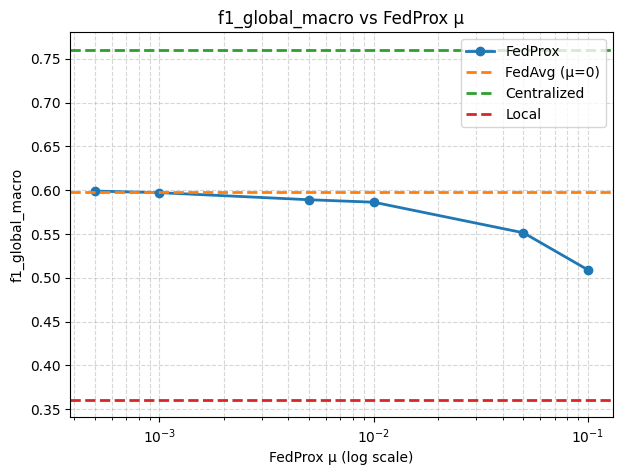

In [7]:
csv_path_mu_1 = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Data\fedprox_mu_sweep_summary_1_15.csv"
csv_path_mu_2 = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Data\fedprox_mu_sweep_summary_05_15.csv"
csv_path_mu_3 = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Data\fedprox_mu_sweep_summary_025_15.csv"
plot_mu_sweep(
    csv_path=csv_path_mu_1,
    metric="f1_global_macro"
)

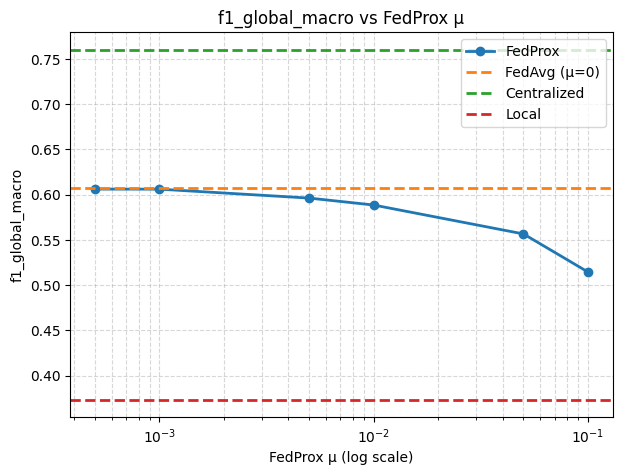

In [8]:
plot_mu_sweep(
    csv_path=csv_path_mu_2,
    metric="f1_global_macro"
)

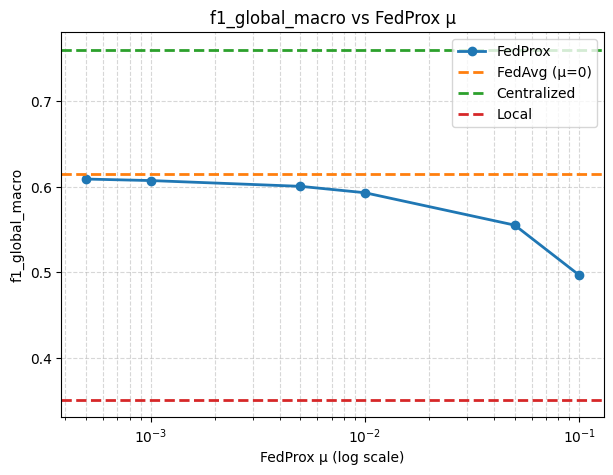

In [9]:
plot_mu_sweep(
    csv_path=csv_path_mu_3,
    metric="f1_global_macro"
)